In [ ]:
!pip install conllu pandas matplotlib seaborn

In [2]:
import os
import requests

# 1.The raw GitHub URLs for the 9 standard treebanks
treebank_urls = {
    "English": "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-train.conllu",
    "Hindi": "https://raw.githubusercontent.com/UniversalDependencies/UD_Hindi-HDTB/master/hi_hdtb-ud-train.conllu",
    "German": "https://raw.githubusercontent.com/UniversalDependencies/UD_German-GSD/master/de_gsd-ud-train.conllu",
    "French": "https://raw.githubusercontent.com/UniversalDependencies/UD_French-GSD/master/fr_gsd-ud-train.conllu",
    "Spanish": "https://raw.githubusercontent.com/UniversalDependencies/UD_Spanish-AnCora/master/es_ancora-ud-train.conllu",
    "Chinese": "https://raw.githubusercontent.com/UniversalDependencies/UD_Chinese-GSD/master/zh_gsd-ud-train.conllu",
    "Japanese": "https://raw.githubusercontent.com/UniversalDependencies/UD_Japanese-GSD/master/ja_gsd-ud-train.conllu",
    "Turkish": "https://raw.githubusercontent.com/UniversalDependencies/UD_Turkish-BOUN/master/tr_boun-ud-train.conllu",
    "Korean": "https://raw.githubusercontent.com/UniversalDependencies/UD_Korean-Kaist/master/ko_kaist-ud-train.conllu"
}
treebank_urls.update({
    "Dutch": "https://raw.githubusercontent.com/UniversalDependencies/UD_Dutch-Alpino/master/nl_alpino-ud-train.conllu",
    "Finnish": "https://raw.githubusercontent.com/UniversalDependencies/UD_Finnish-TDT/master/fi_tdt-ud-train.conllu",
    "Portuguese": "https://raw.githubusercontent.com/UniversalDependencies/UD_Portuguese-Bosque/master/pt_bosque-ud-train.conllu",
    })


# 2. Dictionary to pass to your main analysis script
files_to_process = {}

print("Starting downloads...\n")

# 3. Download loop
for lang, url in treebank_urls.items():
    # Extract the file name from the end of the URL
    file_name = url.split("/")[-1]
    files_to_process[lang] = file_name

    if not os.path.exists(file_name):
        print(f"Fetching {lang} data...")
        response = requests.get(url)

        # Check if the download was successful
        if response.status_code == 200:
            with open(file_name, 'wb') as f:
                f.write(response.content)
            print(f"  -> Saved as {file_name}")
        else:
            print(f"  ❌ Failed to download {lang}. HTTP Status: {response.status_code}")
    else:
        print(f"✅ {lang} data already exists locally ({file_name}).")

print("\nAll available downloads complete!")
print("Your files_to_process dictionary is ready:")
print(files_to_process)

Starting downloads...

Fetching English data...
  -> Saved as en_ewt-ud-train.conllu
Fetching Hindi data...
  -> Saved as hi_hdtb-ud-train.conllu
Fetching German data...
  -> Saved as de_gsd-ud-train.conllu
Fetching French data...
  -> Saved as fr_gsd-ud-train.conllu
Fetching Spanish data...
  -> Saved as es_ancora-ud-train.conllu
Fetching Chinese data...
  -> Saved as zh_gsd-ud-train.conllu
Fetching Japanese data...
  -> Saved as ja_gsd-ud-train.conllu
Fetching Turkish data...
  -> Saved as tr_boun-ud-train.conllu
Fetching Korean data...
  -> Saved as ko_kaist-ud-train.conllu
Fetching Dutch data...
  -> Saved as nl_alpino-ud-train.conllu
Fetching Finnish data...
  -> Saved as fi_tdt-ud-train.conllu
Fetching Portuguese data...
  -> Saved as pt_bosque-ud-train.conllu

All available downloads complete!
Your files_to_process dictionary is ready:
{'English': 'en_ewt-ud-train.conllu', 'Hindi': 'hi_hdtb-ud-train.conllu', 'German': 'de_gsd-ud-train.conllu', 'French': 'fr_gsd-ud-train.conllu',

In [3]:
import os
from conllu import parse_incr
import pandas as pd
from collections import Counter

# 1. Define your languages and their typologies
LANGUAGE_TYPOLOGIES = {
    "English": "SVO", "French": "SVO", "Spanish": "SVO",
    "Chinese": "SVO",
    "Hindi": "SOV", "Japanese": "SOV", "Turkish": "SOV", "Korean": "SOV",
    "German": "Mixed/Flexible"
}
LANGUAGE_TYPOLOGIES.update({
    "Dutch": "Mixed/Flexible",
    "Finnish": "Mixed/Flexible",
    "Portuguese": "Mixed/Flexible",
})
def analyze_dependencies(file_path, language_name):

    """Parses a CoNLL-U file and extracts dependency metrics."""
    records = []

    with open(file_path, "r", encoding="utf-8") as file:
        for sentence in parse_incr(file):
            sentence_length = len([t for t in sentence if isinstance(t["id"], int)])
            import random

            # Create a random permutation of token IDs
            token_ids = [token["id"] for token in sentence if isinstance(token["id"], int)]
            shuffled_ids = token_ids.copy()
            random.shuffle(shuffled_ids)

            # Map original position -> shuffled position
            shuffle_map = dict(zip(token_ids, shuffled_ids))

            tokens_by_id = {token["id"]: token for token in sentence if isinstance(token["id"], int)}

            for token in sentence:
                if not isinstance(token["id"], int) or token["head"] == 0 or token["head"] is None:
                    continue

                dep_id = token["id"]
                head_id = token["head"]
                distance = abs(head_id - dep_id)
                random_distance = abs(shuffle_map[head_id] - shuffle_map[dep_id])

                # Normalize by sentence length
                if sentence_length > 0:
                    normalized_distance = distance / sentence_length
                    normalized_random_distance = random_distance / sentence_length
                else:
                    normalized_distance = 0
                    normalized_random_distance = 0
                # Real direction
                direction = "right" if head_id > dep_id else "left"

                #  NEW: Proper random direction
                random_direction = "right" if shuffle_map[head_id] > shuffle_map[dep_id] else "left"
                min_id = min(dep_id, head_id)
                max_id = max(dep_id, head_id)

                intervening_pos = []
                for mid_id in range(min_id + 1, max_id):
                    if mid_id in tokens_by_id:
                        intervening_pos.append(tokens_by_id[mid_id]["upos"])
                records.append({
                    "Language": language_name,
                    "Typology": LANGUAGE_TYPOLOGIES.get(language_name, "Unknown"),
                    "Dependent_POS": token["upos"],
                    "Head_POS": tokens_by_id[head_id]["upos"] if head_id in tokens_by_id else "ROOT",
                    "Distance": distance,
                    "Num_Intervening": len(intervening_pos),
                    "Direction": direction,
                    "Random_Direction": random_direction,
                    "Random_Distance": random_distance,
                    "Sentence_Length": sentence_length,
                    "Normalized_Distance": normalized_distance,
                    "Normalized_Random_Distance": normalized_random_distance,
                    "Intervening_POS_List": intervening_pos
                })

    return pd.DataFrame(records)

# 2. Process files
files_to_process = {
    "English": "en_ewt-ud-train.conllu",
    "Hindi": "hi_hdtb-ud-train.conllu",
    "German": "de_gsd-ud-train.conllu",
    "French": "fr_gsd-ud-train.conllu",
    "Spanish": "es_ancora-ud-train.conllu",
    "Chinese": "zh_gsd-ud-train.conllu",
    "Japanese": "ja_gsd-ud-train.conllu",
    "Turkish": "tr_boun-ud-train.conllu",
    "Korean": "ko_kaist-ud-train.conllu"
}
files_to_process.update({
    "Dutch": "nl_alpino-ud-train.conllu",
    "Finnish": "fi_tdt-ud-train.conllu",
    "Portuguese": "pt_bosque-ud-train.conllu",
})
all_dataframes = []
for lang, path in files_to_process.items():
    if os.path.exists(path):
        print(f"Processing {lang}...")
        df = analyze_dependencies(path, lang)
        all_dataframes.append(df)
    else:
        print(f"⚠️ Could not find file for {lang} at path: {path}")

# Combine into the master dataframe
if len(all_dataframes) > 0:
    master_df = pd.concat(all_dataframes, ignore_index=True)
    print("\n✅ Data processing complete! master_df is ready for analysis.")
else:
    print("\n❌ Error: No files were processed.")

Processing English...
Processing Hindi...
Processing German...
Processing French...
Processing Spanish...
Processing Chinese...
Processing Japanese...
Processing Turkish...
Processing Korean...
Processing Dutch...
Processing Finnish...
Processing Portuguese...

✅ Data processing complete! master_df is ready for analysis.


--- OBJECTIVE 1: Top Intervening POS Categories (All Data) ---

NOUN: 1,183,004 occurrences
ADP: 972,283 occurrences
DET: 766,392 occurrences
PUNCT: 483,388 occurrences
PROPN: 480,390 occurrences
ADJ: 432,934 occurrences
ADV: 312,553 occurrences
VERB: 300,174 occurrences
PRON: 272,701 occurrences
AUX: 272,025 occurrences


/tmp/ipykernel_10887/2741258879.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pos_df, x="POS_Tag", y="Frequency", palette="magma")


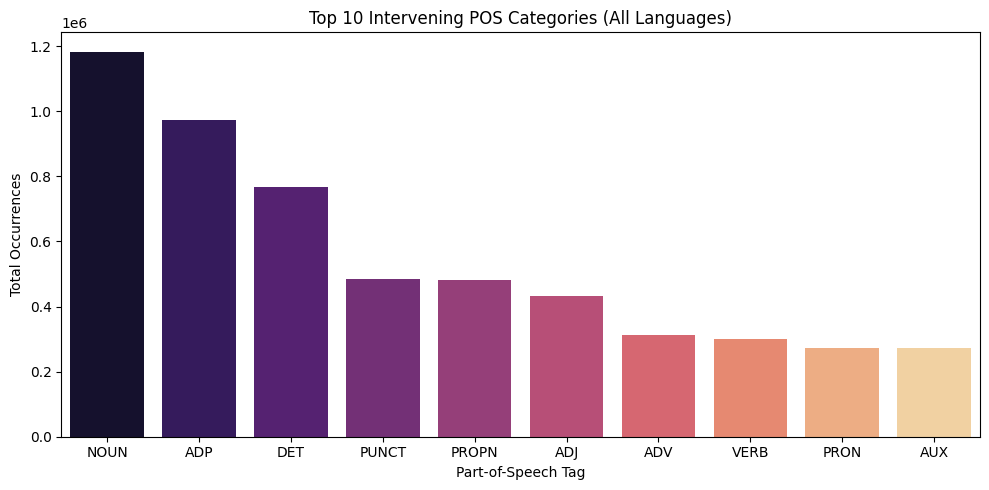

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter

# OBJECTIVE 1: Most Frequent Intervening POS
if 'master_df' in locals():
    print("--- OBJECTIVE 1: Top Intervening POS Categories (All Data) ---\n")

    # Flatten the lists of POS tags
    all_pos = [pos for pos_list in master_df["Intervening_POS_List"] for pos in pos_list]
    pos_counts = Counter(all_pos)

    # Print the top 10 text output
    for pos, count in pos_counts.most_common(10):
        print(f"{pos}: {count:,} occurrences")

    # Plotting
    pos_df = pd.DataFrame(pos_counts.most_common(10), columns=["POS_Tag", "Frequency"])
    plt.figure(figsize=(10, 5))
    sns.barplot(data=pos_df, x="POS_Tag", y="Frequency", palette="magma")
    plt.title("Top 10 Intervening POS Categories (All Languages)")
    plt.ylabel("Total Occurrences")
    plt.xlabel("Part-of-Speech Tag")
    plt.tight_layout()
    plt.show()
else:
    print("Please run the Data Processing block first!")

--- Intervening Words vs Sentence Length ---

Length_Bin
1-10     1.052731
11-20    1.840780
21-30    2.459543
31-40    2.768994
40+      3.078624
Name: Num_Intervening, dtype: float64


/tmp/ipykernel_10887/3316087082.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_stats = master_df.groupby("Length_Bin")["Num_Intervening"].mean()


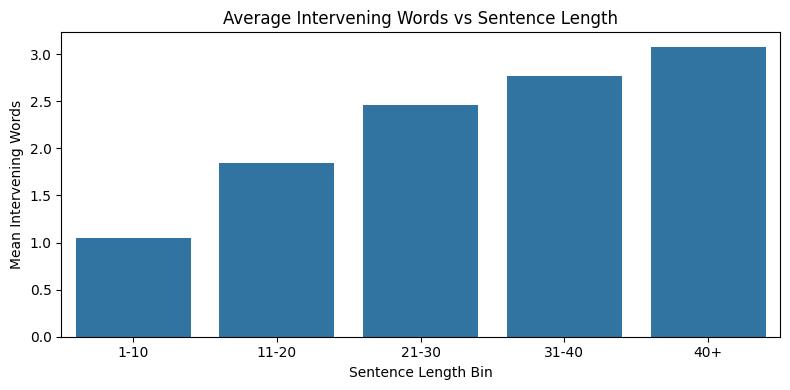

In [6]:
# OBJECTIVE: Intervening Words vs Sentence Length

if 'master_df' in locals():
    print("--- Intervening Words vs Sentence Length ---\n")

    # Bin sentence lengths
    master_df["Length_Bin"] = pd.cut(
        master_df["Sentence_Length"],
        bins=[0, 10, 20, 30, 40, 100],
        labels=["1-10", "11-20", "21-30", "31-40", "40+"]
    )

    # Compute mean intervening words per bin
    bin_stats = master_df.groupby("Length_Bin")["Num_Intervening"].mean()
    print(bin_stats)

    # Plot
    plt.figure(figsize=(8, 4))
    sns.barplot(x=bin_stats.index, y=bin_stats.values)
    plt.title("Average Intervening Words vs Sentence Length")
    plt.xlabel("Sentence Length Bin")
    plt.ylabel("Mean Intervening Words")
    plt.tight_layout()
    plt.show()

else:
    print("Run processing first!")

--- OBJECTIVE 3: Mean Dependency Distance per Language ---

Language
Chinese       0.14
Dutch         0.19
English       0.16
Finnish       0.19
French        0.12
German        0.17
Hindi         0.15
Japanese      0.10
Korean        0.17
Portuguese    0.12
Spanish       0.10
Turkish       0.18
Name: Normalized_Distance, dtype: float64


/tmp/ipykernel_10887/3391808046.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=distance_by_lang.index, y=distance_by_lang.values, palette="crest")


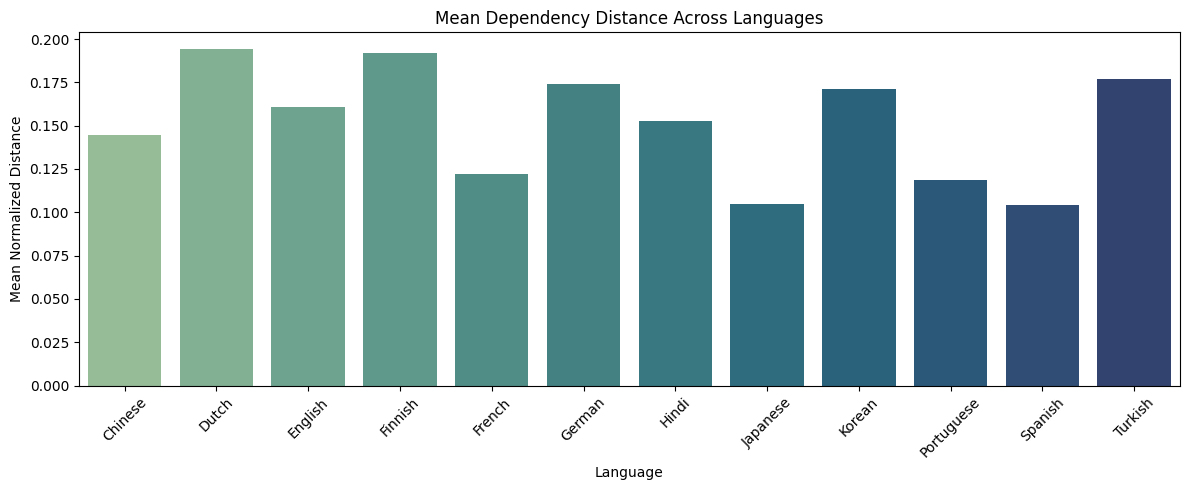

In [8]:
# OBJECTIVE 3: Dependency Distances by Language

if 'master_df' in locals():
    print("--- OBJECTIVE 3: Mean Dependency Distance per Language ---\n")

    # Calculate and print mean distances
    distance_by_lang = master_df.groupby("Language")["Normalized_Distance"].mean()
    print(distance_by_lang.round(2))

    # Plotting
    plt.figure(figsize=(12, 5))
    sns.barplot(x=distance_by_lang.index, y=distance_by_lang.values, palette="crest")
    plt.title("Mean Dependency Distance Across Languages")
    plt.ylabel("Mean Normalized Distance")
    plt.xlabel("Language")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Please run the Data Processing block first!")

--- OBJECTIVE 4: Dependency Distances by Typology ---

                    count      mean       std       min       25%       50%  \
Typology                                                                      
Mixed/Flexible   739058.0  0.170107  0.193550  0.004202  0.047619  0.090909   
SOV              795380.0  0.152198  0.178829  0.007353  0.050000  0.080000   
SVO             1065600.0  0.123717  0.166836  0.002564  0.033333  0.061224   

                     75%       max  
Typology                            
Mixed/Flexible  0.200000  0.989796  
SOV             0.166667  0.985714  
SVO             0.129032  0.993377  

Generating Typological POS Heatmap...


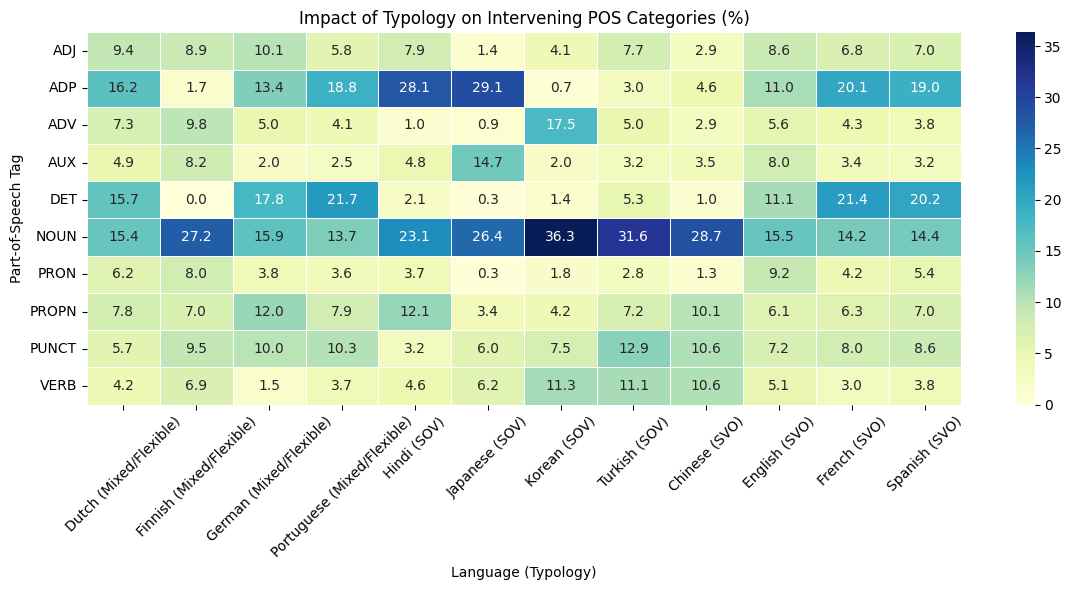

In [9]:
# OBJECTIVE 4: Typological Differences

if 'master_df' in locals():
    print("--- OBJECTIVE 4: Dependency Distances by Typology ---\n")

    # Print comparison stats
    typology_stats = master_df.groupby("Typology")["Normalized_Distance"].describe()
    print(typology_stats)

    print("\nGenerating Typological POS Heatmap...")

    # Heatmap logic for type of intervening words
    all_pos = [pos for pos_list in master_df["Intervening_POS_List"] for pos in pos_list]
    top_10_pos = [pos for pos, count in Counter(all_pos).most_common(10)]

    heatmap_data = []
    for lang in master_df["Language"].unique():
        lang_df = master_df[master_df["Language"] == lang]
        typology = lang_df["Typology"].iloc[0]

        lang_pos = [pos for pos_list in lang_df["Intervening_POS_List"] for pos in pos_list]
        lang_counts = Counter(lang_pos)
        total = len(lang_pos) if len(lang_pos) > 0 else 1

        for pos in top_10_pos:
            heatmap_data.append({
                "Language": f"{lang} ({typology})",
                "Typology": typology,
                "POS_Tag": pos,
                "Percentage": (lang_counts.get(pos, 0) / total) * 100
            })

    viz_df = pd.DataFrame(heatmap_data).sort_values(by=["Typology", "Language"])
    pivot_df = viz_df.pivot(index="POS_Tag", columns="Language", values="Percentage")
    pivot_df = pivot_df[viz_df["Language"].unique()] # Keep sorted order

    # Plotting
    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_df, annot=True, cmap="YlGnBu", fmt=".1f", linewidths=.5)
    plt.title("Impact of Typology on Intervening POS Categories (%)")
    plt.ylabel("Part-of-Speech Tag")
    plt.xlabel("Language (Typology)")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Please run the Data Processing block first!")

--- OBJECTIVE 5: Dependency Direction (Left vs Right) ---

Overall Direction Distribution (%):
Direction
right    60.45
left     39.55
Name: proportion, dtype: float64

Direction Distribution by Language (%):
Direction    left  right
Language                
Chinese     37.74  62.26
Dutch       35.68  64.32
English     38.32  61.68
Finnish     42.84  57.16
French      42.83  57.17
German      36.17  63.83
Hindi       41.61  58.39
Japanese    51.72  48.28
Korean      24.95  75.05
Portuguese  44.42  55.58
Spanish     43.51  56.49
Turkish     31.43  68.57


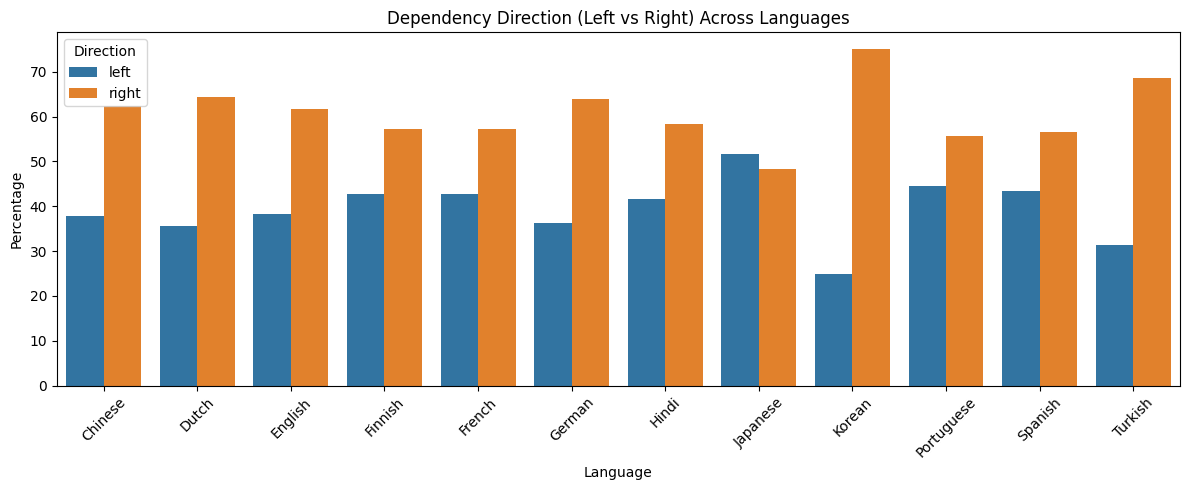

In [ ]:
# OBJECTIVE 5: Dependency Directionality
if 'master_df' in locals():
    print("--- OBJECTIVE 5: Dependency Direction (Left vs Right) ---\n")

    # Overall distribution
    direction_counts = master_df["Direction"].value_counts(normalize=True) * 100
    print("Overall Direction Distribution (%):")
    print(direction_counts.round(2))

    # By language
    print("\nDirection Distribution by Language (%):")
    direction_by_lang = (
        master_df.groupby(["Language", "Direction"])
        .size()
        .unstack()
        .apply(lambda x: x / x.sum() * 100, axis=1)
    )
    print(direction_by_lang.round(2))

    # Plot
    import matplotlib.pyplot as plt
    import seaborn as sns

    direction_by_lang = direction_by_lang.reset_index().melt(
        id_vars="Language", var_name="Direction", value_name="Percentage"
    )

    plt.figure(figsize=(12, 5))
    sns.barplot(data=direction_by_lang, x="Language", y="Percentage", hue="Direction")
    plt.title("Dependency Direction (Left vs Right) Across Languages")
    plt.ylabel("Percentage")
    plt.xlabel("Language")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("Please run the Data Processing block first!")

--- OBJECTIVE 6: Direction by Typology ---

Direction        left  right
Typology                    
Mixed/Flexible  39.25  60.75
SOV             36.75  63.25
SVO             41.84  58.16


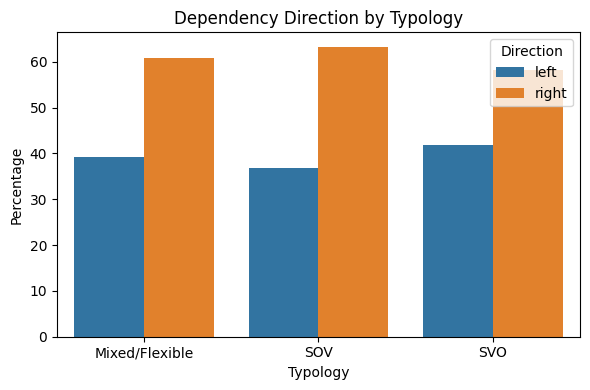

In [ ]:
# OBJECTIVE 6: Direction by Typology

if 'master_df' in locals():
    print("--- OBJECTIVE 6: Direction by Typology ---\n")

    direction_by_typology = (
        master_df.groupby(["Typology", "Direction"])
        .size()
        .unstack()
        .apply(lambda x: x / x.sum() * 100, axis=1)
    )

    print(direction_by_typology.round(2))

    # Plot
    direction_by_typology = direction_by_typology.reset_index().melt(
        id_vars="Typology", var_name="Direction", value_name="Percentage"
    )

    plt.figure(figsize=(6, 4))
    sns.barplot(data=direction_by_typology, x="Typology", y="Percentage", hue="Direction")
    plt.title("Dependency Direction by Typology")
    plt.ylabel("Percentage")
    plt.xlabel("Typology")
    plt.tight_layout()
    plt.show()

else:
    print("Please run the Data Processing block first!")

--- OBJECTIVE: Real vs Random Dependency Distance ---

Mean Real Distance: 0.15
Mean Random Distance: 0.35


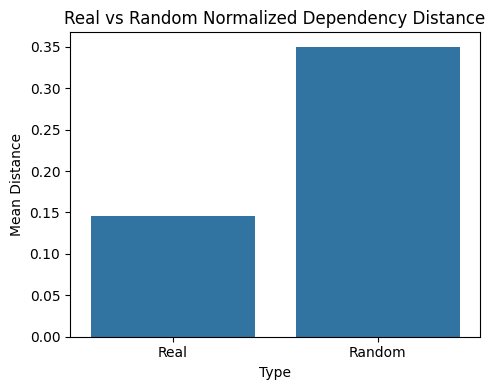

In [10]:
# OBJECTIVE: Real vs Random Dependency Distance

if 'master_df' in locals():
    print("--- OBJECTIVE: Real vs Random Dependency Distance ---\n")

    real_mean = master_df["Normalized_Distance"].mean()
    random_mean = master_df["Normalized_Random_Distance"].mean()

    print(f"Mean Real Distance: {real_mean:.2f}")
    print(f"Mean Random Distance: {random_mean:.2f}")

    # Plot comparison
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd

    compare_df = pd.DataFrame({
        "Type": ["Real", "Random"],
        "Mean Distance": [real_mean, random_mean]
    })

    plt.figure(figsize=(5, 4))
    sns.barplot(data=compare_df, x="Type", y="Mean Distance")
    plt.title("Real vs Random Normalized Dependency Distance")
    plt.tight_layout()
    plt.show()

else:
    print("Please run the Data Processing block first!")

--- OBJECTIVE: Real vs Random by Language ---

            Normalized_Distance  Normalized_Random_Distance
Language                                                   
Chinese                    0.14                        0.35
Dutch                      0.19                        0.35
English                    0.16                        0.35
Finnish                    0.19                        0.36
French                     0.12                        0.35
German                     0.17                        0.35
Hindi                      0.15                        0.35
Japanese                   0.10                        0.35
Korean                     0.17                        0.36
Portuguese                 0.12                        0.35
Spanish                    0.10                        0.34
Turkish                    0.18                        0.36


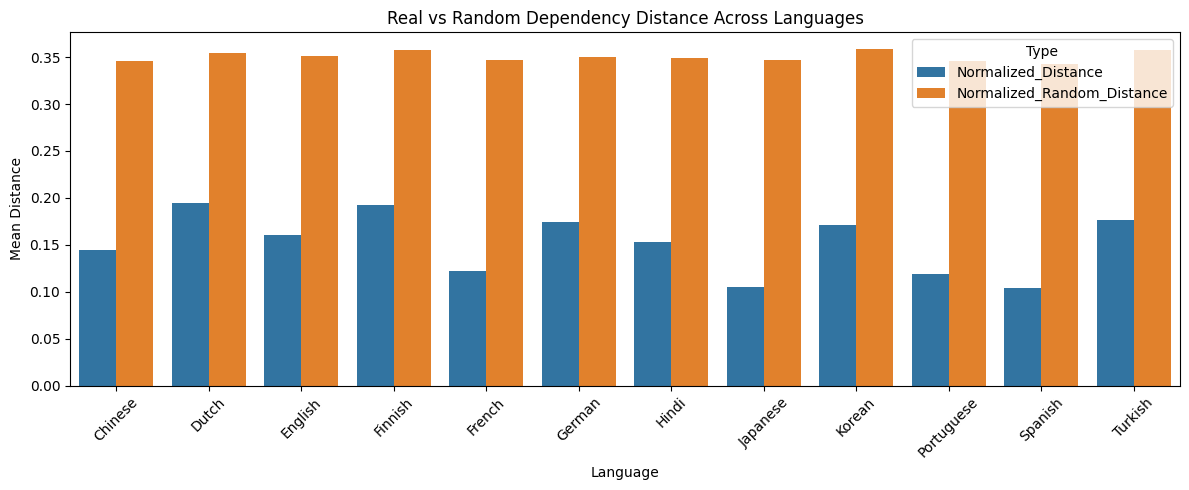

In [11]:
# OBJECTIVE: Real vs Random by Language

if 'master_df' in locals():
    print("--- OBJECTIVE: Real vs Random by Language ---\n")

    lang_compare = master_df.groupby("Language")[["Normalized_Distance", "Normalized_Random_Distance"]].mean()
    print(lang_compare.round(2))

    # Plot
    lang_compare = lang_compare.reset_index().melt(
        id_vars="Language",
        var_name="Type",
        value_name="Mean Distance"
    )

    plt.figure(figsize=(12, 5))
    sns.barplot(data=lang_compare, x="Language", y="Mean Distance", hue="Type")
    plt.title("Real vs Random Dependency Distance Across Languages")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("Please run the Data Processing block first!")

--- Real vs Random Direction by Typology ---

Real Direction (%):
Direction        left  right
Typology                    
Mixed/Flexible  39.25  60.75
SOV             36.75  63.25
SVO             41.84  58.16

Random Direction (%):
Random_Direction   left  right
Typology                      
Mixed/Flexible    49.99  50.01
SOV               50.03  49.97
SVO               50.10  49.90


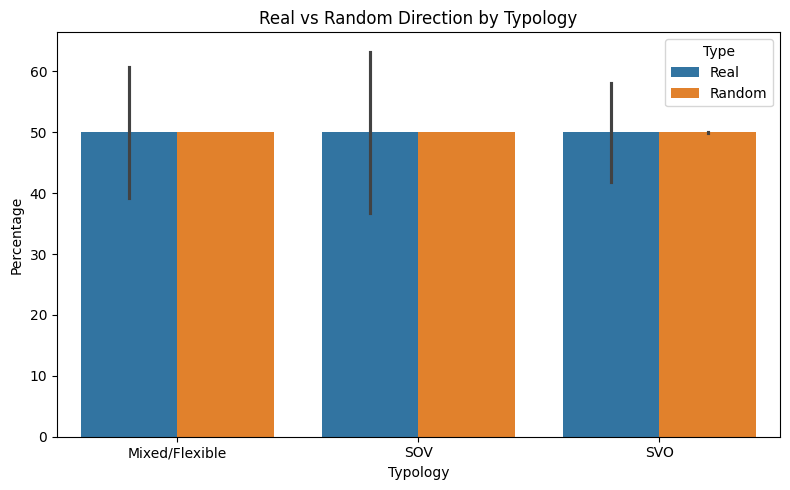

In [ ]:
# ==========================================
# Real vs Random Direction by Typology
# ==========================================

if 'master_df' in locals():
    print("--- Real vs Random Direction by Typology ---\n")

    # Real
    real_dir = (
        master_df.groupby(["Typology", "Direction"])
        .size()
        .unstack()
        .apply(lambda x: x / x.sum() * 100, axis=1)
    )

    # Random (now CORRECT)
    random_dir = (
        master_df.groupby(["Typology", "Random_Direction"])
        .size()
        .unstack()
        .apply(lambda x: x / x.sum() * 100, axis=1)
    )

    print("Real Direction (%):")
    print(real_dir.round(2))

    print("\nRandom Direction (%):")
    print(random_dir.round(2))

    # Combine
    real_dir["Type"] = "Real"
    random_dir["Type"] = "Random"

    combined = pd.concat([real_dir, random_dir]).reset_index()
    combined = combined.melt(
        id_vars=["Typology", "Type"],
        var_name="Direction",
        value_name="Percentage"
    )

    # Plot
    plt.figure(figsize=(8, 5))
    sns.barplot(data=combined, x="Typology", y="Percentage", hue="Type")
    plt.title("Real vs Random Direction by Typology")
    plt.ylabel("Percentage")
    plt.tight_layout()
    plt.show()

else:
    print("Please run the Data Processing block first!")

--- Real vs Random Intervening POS ---

Type   Random   Real
POS                 
ADJ      5.08   7.11
ADP      6.61  15.97
ADV      3.47   5.13
AUX      2.39   4.47
DET      4.73  12.59
NOUN    31.49  19.44
PRON     2.80   4.48
PROPN    8.38   7.89
PUNCT    6.06   7.94
VERB    22.64   4.93


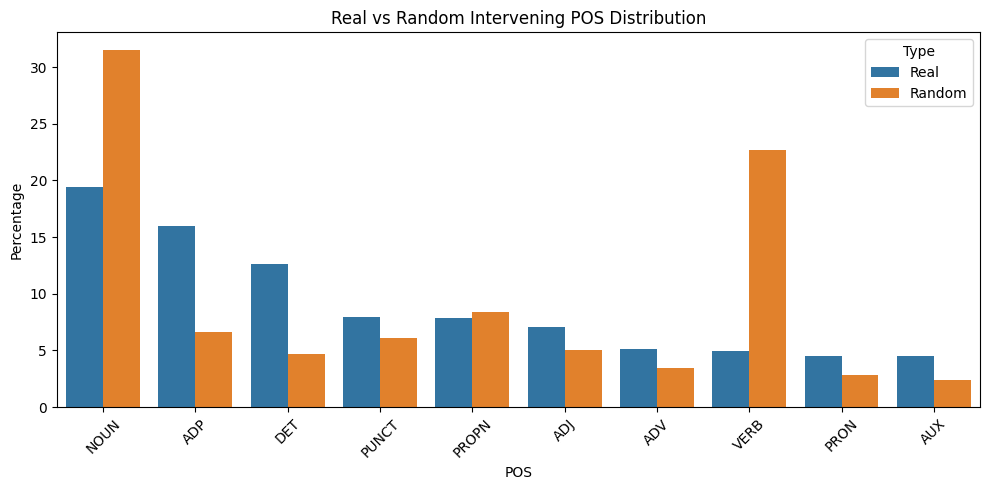

In [ ]:
# ==========================================
# OBJECTIVE: Intervening POS (Real vs Random)
# ==========================================

if 'master_df' in locals():
    print("--- Real vs Random Intervening POS ---\n")

    import random

    # Step 1: Collect REAL intervening POS
    real_pos = [
        pos for pos_list in master_df["Intervening_POS_List"]
        for pos in pos_list
    ]

    real_counts = Counter(real_pos)

    # Step 2: Generate RANDOM intervening POS
    all_possible_pos = master_df["Dependent_POS"].tolist() + master_df["Head_POS"].tolist()

    random_pos = []
    for _, row in master_df.iterrows():
        k = int(row["Random_Distance"])  # number of intervening words
        if k > 0:
            sampled = random.choices(all_possible_pos, k=k)
            random_pos.extend(sampled)

    random_counts = Counter(random_pos)

    # Step 3: Normalize to percentages
    total_real = sum(real_counts.values())
    total_random = sum(random_counts.values())

    # Top POS based on real data
    top_pos = [pos for pos, _ in real_counts.most_common(10)]

    compare_data = []
    for pos in top_pos:
        compare_data.append({
            "POS": pos,
            "Type": "Real",
            "Percentage": (real_counts[pos] / total_real) * 100
        })
        compare_data.append({
            "POS": pos,
            "Type": "Random",
            "Percentage": (random_counts[pos] / total_random) * 100
        })

    compare_df = pd.DataFrame(compare_data)

    print(compare_df.pivot(index="POS", columns="Type", values="Percentage").round(2))

    # Plot
    plt.figure(figsize=(10, 5))
    sns.barplot(data=compare_df, x="POS", y="Percentage", hue="Type")
    plt.title("Real vs Random Intervening POS Distribution")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

else:
    print("Please run the Data Processing block first!")

In [ ]:
# Find extreme cases
extreme = master_df[master_df["Num_Intervening"] > 100]

print(f"Number of extreme cases: {len(extreme)}")
print(extreme[["Language", "Distance", "Num_Intervening"]].head())

Number of extreme cases: 78
       Language  Distance  Num_Intervening
100348  English       155              154
113659  English       108              107
113670  English       119              118
113681  English       130              129
296659    Hindi       110              109


In [ ]:
idx = extreme.index[0]
print(master_df.loc[idx])

Language                                                          English
Typology                                                              SVO
Dependent_POS                                                       PUNCT
Head_POS                                                             VERB
Distance                                                              155
Num_Intervening                                                       154
Direction                                                            left
Random_Direction                                                     left
Random_Distance                                                        74
Intervening_POS_List    [PART, VERB, ADP, PROPN, PROPN, PUNCT, CCONJ, ...
Name: 100348, dtype: object
